In [ ]:
### 

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import yfinance as yf
from datetime import datetime, timedelta

In [8]:
instruments = ['SPY', 'BND']

In [18]:
rets = yf.download(instruments, interval='1mo')['Close']

/var/folders/85/5fry4xk160lfn0vlgt62q99m0000gn/T/ipykernel_8049/444375414.py:1: FutureWarning: YF.download() has changed argument auto_adjust default to True
  rets = yf.download(instruments, interval='1mo')['Close']
[*********************100%***********************]  2 of 2 completed


In [19]:
rets

Ticker,BND,SPY
Date,,
1993-01-01,NaN,24.241409
1993-02-01,NaN,24.500040
1993-03-01,NaN,24.931053
1993-04-01,NaN,24.407846
1993-05-01,NaN,25.066130
...,...,...
2025-10-01,73.373573,680.050537
2025-11-01,73.805527,681.376587
2025-12-01,73.344734,679.910889


In [20]:
rets.dropna(inplace=True)

In [21]:
rets = rets.to_period('D')

In [22]:
rets

Ticker,BND,SPY
Date,,
2007-04-01,41.904099,104.673813
2007-05-01,41.504459,108.224358
2007-06-01,41.301922,106.184364
2007-07-01,41.696018,103.303001
2007-08-01,42.275009,104.628693
...,...,...
2025-10-01,73.373573,680.050537
2025-11-01,73.805527,681.376587
2025-12-01,73.344734,679.910889


<Axes: xlabel='Date'>

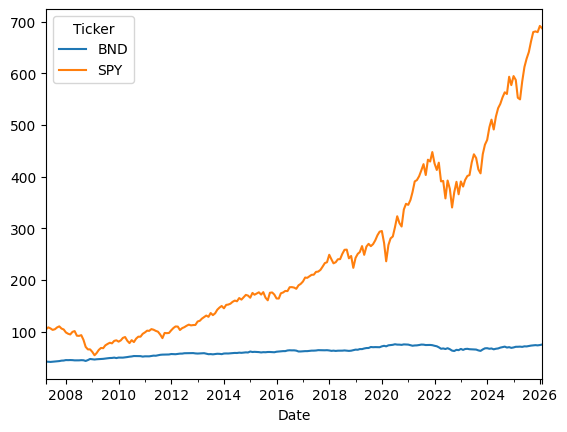

In [23]:
rets.plot()

0.30000000000000004

In [26]:
returns = rets.pct_change().dropna()

<Axes: xlabel='Date'>

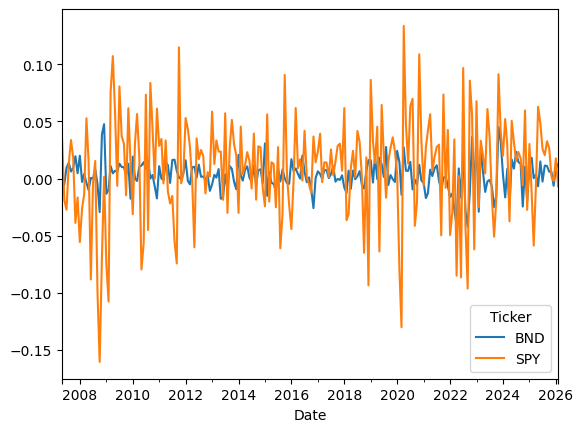

In [27]:
returns.plot()

In [28]:
### Compound Returns

In [29]:
compound_returns  = (1 + returns).prod() -1
(compound_returns * 100).round(2).astype('str') + '%'

Ticker
BND     78.81%
SPY    556.66%
dtype: object

In [30]:
returns.index

PeriodIndex(['2007-05-01', '2007-06-01', '2007-07-01', '2007-08-01',
             '2007-09-01', '2007-10-01', '2007-11-01', '2007-12-01',
             '2008-01-01', '2008-02-01',
             ...
             '2025-05-01', '2025-06-01', '2025-07-01', '2025-08-01',
             '2025-09-01', '2025-10-01', '2025-11-01', '2025-12-01',
             '2026-01-01', '2026-02-01'],
            dtype='period[D]', name='Date', length=226)

In [31]:
### Volatility
volatility = returns.std()
(volatility * 100).round(2).astype('str') + '%'

Ticker
BND    1.34%
SPY    4.52%
dtype: object

In [32]:
### Annualized Returns


In [33]:
# Monthly returns
(returns + 1)**12 -1

Ticker,BND,SPY
Date,,
2007-05-01,-0.108628,0.492257
2007-06-01,-0.057012,-0.204158
2007-07-01,0.120706,-0.281166
2007-08-01,0.179966,0.165344
2007-09-01,0.077135,0.490343
...,...,...
2025-10-01,0.076176,0.371516
2025-11-01,0.072977,0.023652
2025-12-01,-0.072400,-0.025510


In [ ]:
# Annualized Volatility
(volatility * np.sqrt(12) * 100).round(2).astype('str') + '%'